In [1]:
# ==============================================================================
# Step 24: Load Preprocessed Data
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, 
                             RocCurveDisplay, PrecisionRecallDisplay)

X_train_full = np.load('../data/X_train_processed.npy')
y_train_full = np.load('../data/y_train.npy')
X_test = np.load('../data/X_test_processed.npy')
test_id = np.load('../data/test_id.npy')

# Split training data into Train and Validation sets for generating charts
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

print("Step 24 Completed: Preprocessed data loaded and Train/Validation split created.")
print(f"Key Finding: Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}. Validation set allows for proper plotting of CM and Curves.\n")


Step 24 Completed: Preprocessed data loaded and Train/Validation split created.
Key Finding: Train size: 600000, Val size: 150000. Validation set allows for proper plotting of CM and Curves.



In [2]:
# ==============================================================================
# Step 25: Create a Reusable Evaluation Function
# ==============================================================================
def evaluate_and_plot(model, X_train, y_train, X_val, y_val, model_name):
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    
    # Predict on Validation Data
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    # Predict on Training Data (for Train Accuracy)
    y_train_pred = model.predict(X_train)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f"--- Classification Report for {model_name} ---")
    print(classification_report(y_val, y_pred))
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../charts/{model_name.replace(" ", "_")}_Confusion_Matrix.png', bbox_inches='tight')
    plt.show() 
    
    # 2. ROC Curve
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_val, y_prob, ax=ax, name=model_name)
    plt.title(f'{model_name} ROC Curve')
    plt.tight_layout()
    plt.savefig(f'../charts/{model_name.replace(" ", "_")}_ROC_Curve.png', bbox_inches='tight')
    plt.show() 
    
    # 3. Precision-Recall
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_val, y_prob, ax=ax, name=model_name)
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.tight_layout()
    plt.savefig(f'../charts/{model_name.replace(" ", "_")}_PR_Curve.png', bbox_inches='tight')
    plt.show() 
    
    return {
        "Model": model_name, 
        "Train Accuracy": train_acc, 
        "Validation Accuracy": val_acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1 Score": f1, 
        "ROC AUC": roc_auc
    }

print("Step 25 Completed: Reusable Evaluation Function created.")
print("Key Finding: Function outputs train/val accuracy, and displays/saves CM, ROC, and PR curves.\n")


Step 25 Completed: Reusable Evaluation Function created.
Key Finding: Function outputs train/val accuracy, and displays/saves CM, ROC, and PR curves.



In [3]:
# ==============================================================================
# Step 26: Initialize Models
# ==============================================================================
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(class_weight="balanced", n_estimators=50, max_depth=6, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train))/sum(y_train), n_estimators=50, max_depth=6, random_state=42, n_jobs=-1, eval_metric='logloss'),
    "Deep Neural Network": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=30, early_stopping=True, random_state=42)
}

print("Step 26 Completed: Baseline models initialized.")
print("Key Finding: All applicable models have class-weighting applied to combat the 88:12 imbalance.\n")


Step 26 Completed: Baseline models initialized.
Key Finding: All applicable models have class-weighting applied to combat the 88:12 imbalance.



Training Logistic Regression...
--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.87      0.92    131902
           1       0.48      0.88      0.62     18098

    accuracy                           0.87    150000
   macro avg       0.73      0.88      0.77    150000
weighted avg       0.92      0.87      0.89    150000



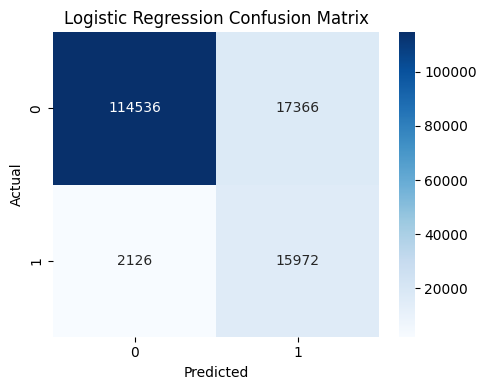

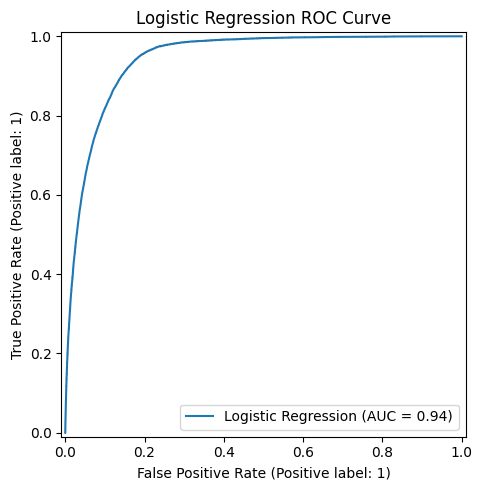

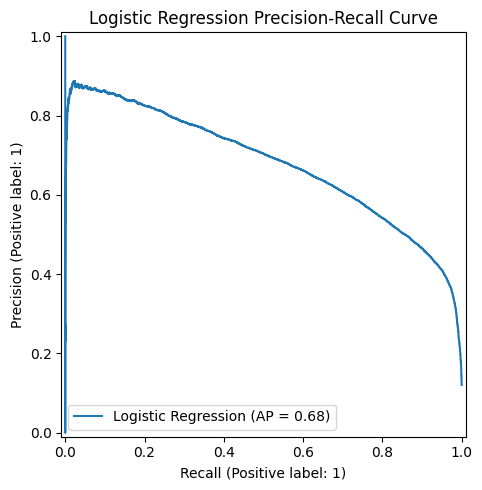

Training Decision Tree...
--- Classification Report for Decision Tree ---
              precision    recall  f1-score   support

           0       0.99      0.84      0.91    131902
           1       0.44      0.91      0.59     18098

    accuracy                           0.85    150000
   macro avg       0.71      0.87      0.75    150000
weighted avg       0.92      0.85      0.87    150000



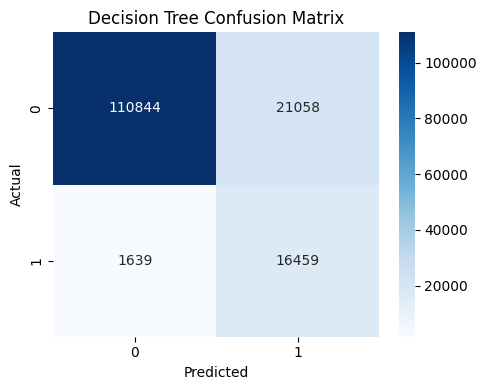

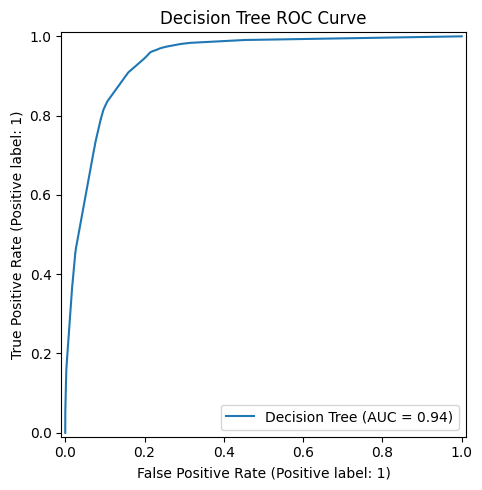

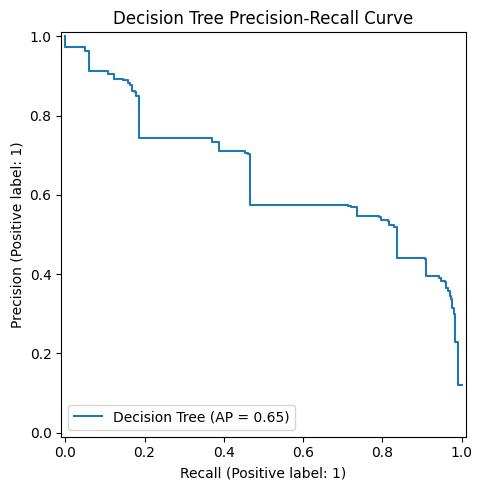

Training Random Forest...
--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.84      0.91    131902
           1       0.44      0.94      0.60     18098

    accuracy                           0.85    150000
   macro avg       0.71      0.89      0.75    150000
weighted avg       0.92      0.85      0.87    150000



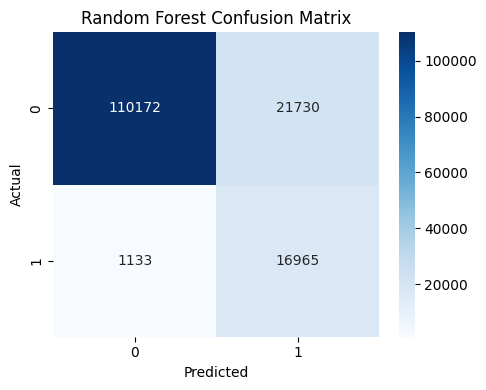

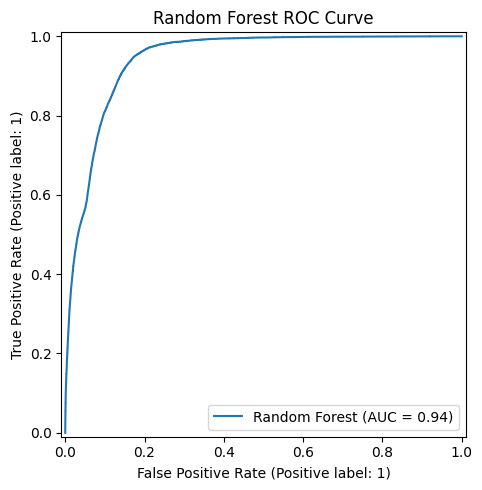

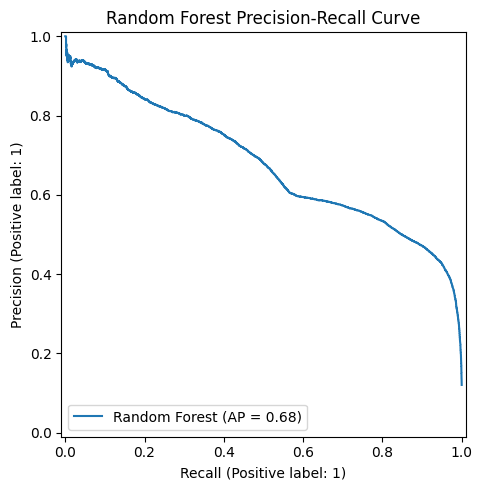

Training LightGBM...
[LightGBM] [Info] Number of positive: 72390, number of negative: 527610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1055
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
--- Classification Report for LightGBM ---
              precision    recall  f1-score   support

           0       0.99      0.85      0.92    131902
           1       0.47      0.94      0.62     18098

    accuracy                           0.86    150000
   macro avg       0.73      0.90      0.77    150000
weighted avg       0.93      0.86      0.88    150000



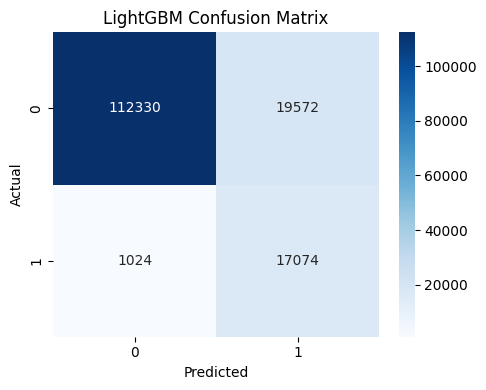

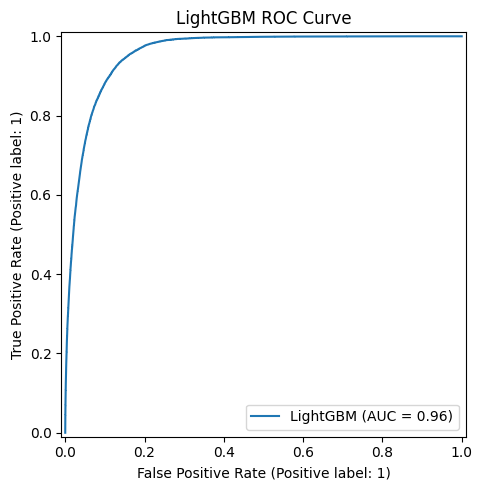

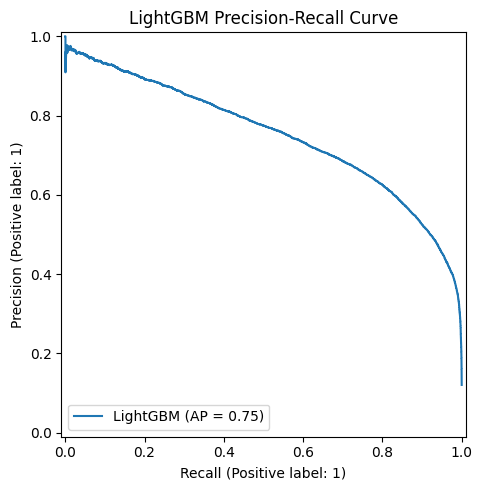

Training XGBoost...
--- Classification Report for XGBoost ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    131902
           1       0.51      0.94      0.66     18098

    accuracy                           0.88    150000
   macro avg       0.75      0.91      0.79    150000
weighted avg       0.93      0.88      0.90    150000



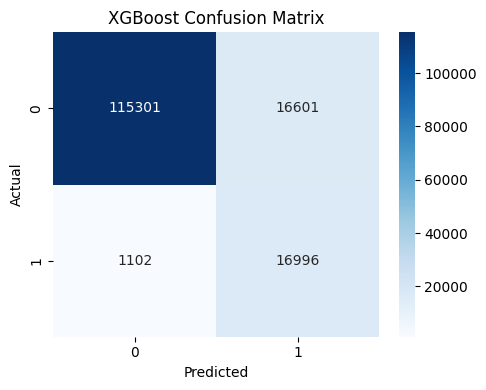

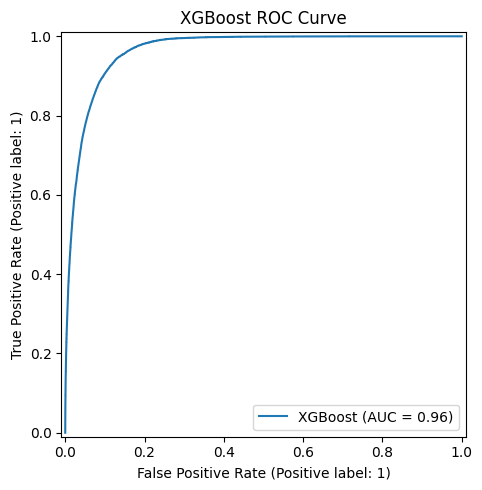

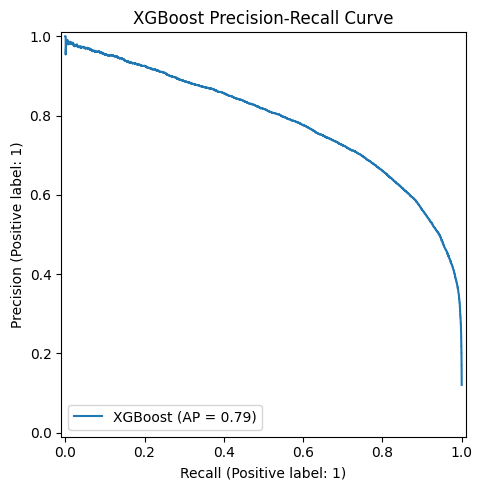

Training Deep Neural Network...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Classification Report for Deep Neural Network ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96    131902
           1       0.73      0.68      0.71     18098

    accuracy                           0.93    150000
   macro avg       0.84      0.82      0.83    150000
weighted avg       0.93      0.93      0.93    150000



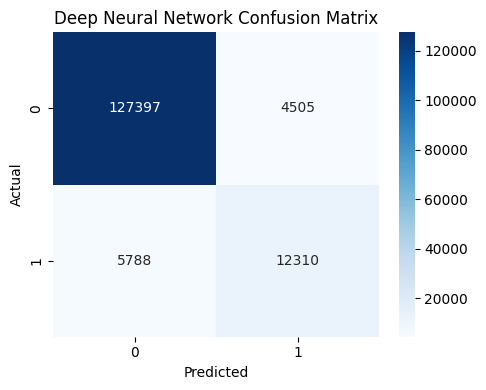

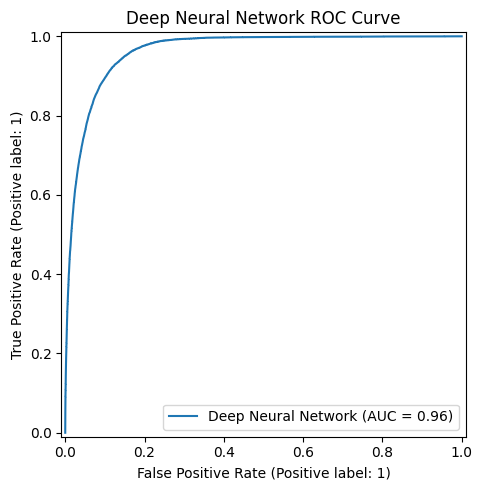

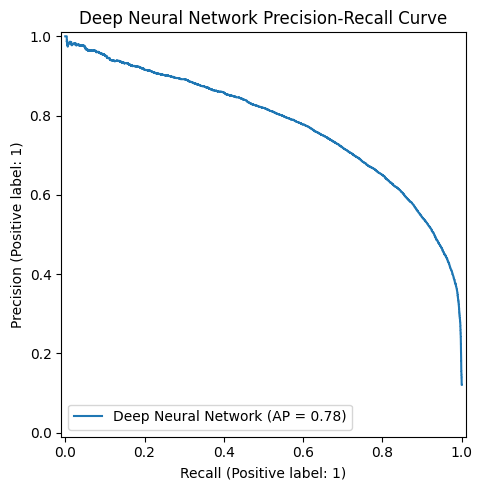

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,0.883287,0.881980,0.505879,0.939109,0.657549,0.964715
1,Deep Neural Network,0.933947,0.931380,0.732084,0.680186,0.705181,0.962322
2,LightGBM,0.862433,0.862693,0.465917,0.943419,0.623776,0.958702
3,Logistic Regression,0.868880,0.870053,0.479093,0.882528,0.621044,0.943918
4,Random Forest,0.847242,0.847580,0.438429,0.937396,0.597433,0.942966
5,Decision Tree,0.847767,0.848687,0.438708,0.909438,0.591891,0.937863


Step 27 Completed: All models evaluated.
Key Finding: The best performing baseline model is **XGBoost** with a ROC AUC of 0.964715.



In [4]:
# ==============================================================================
# Step 27: Train and Evaluate Models
# ==============================================================================
from sklearn.base import clone

results_list = []
for name, model in models.items():
    res = evaluate_and_plot(model, X_train, y_train, X_val, y_val, name)
    results_list.append(res)

results_df = pd.DataFrame(results_list).sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)
display(results_df)

# Programmatically identify the absolute best baseline model based on ROC AUC
best_baseline_name = results_df.iloc[0]['Model']
best_baseline_score = results_df.iloc[0]['ROC AUC']

print("Step 27 Completed: All models evaluated.")
print(f"Key Finding: The best performing baseline model is **{best_baseline_name}** with a ROC AUC of {best_baseline_score:.6f}.\n")


In [5]:
# ==============================================================================
# Step 28: DYNAMIC Hyperparameter Tuning on the Winning Model
# ==============================================================================

print(f"--- Hyperparameter Tuning on Winner: {best_baseline_name} ---")

# Define parameter grids for all possible models
# IMPORTANT: Adjust the list values inside the dictionary for the model we want to experiment with.
tuning_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10], 
        'solver': ['liblinear', 'lbfgs']
    },
    "Decision Tree": {
        'max_depth': [4, 6, 8, 10], 
        'min_samples_split': [2, 5, 10]
    },
    "Random Forest": {
        'n_estimators': [50, 100], 
        'max_depth': [6, 8, 10]
    },
    "LightGBM": {
        'n_estimators': [50, 100, 200], 
        'learning_rate': [0.01, 0.05, 0.1], 
        'max_depth': [4, 6, 8]
    },
    "XGBoost": {
        'n_estimators': [150, 250, 300], 
        'learning_rate': [0.05, 0.1], 
        'max_depth': [6, 8],
        'subsample': [0.9], 
        'colsample_bytree': [0.9]
    },
    "Deep Neural Network": {
        'hidden_layer_sizes': [(32, 16), (64, 32)], 
        'alpha': [0.0001, 0.001]
    }
}

# Fetch a FRESH, un-fitted instance of the winning model to avoid parameter leakage
base_estimator = clone(models[best_baseline_name])

# Fetch the correct grid specifically mapped to the winning model
param_grid = tuning_grids[best_baseline_name]

# Run Grid Search
grid_search = GridSearchCV(
    estimator=base_estimator, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    cv=3, 
    verbose=1, 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Save the best estimator found during the grid search
tuned_model = grid_search.best_estimator_


# Extract the standard deviation of the ROC-AUC across the 3 folds for the best model
best_index = grid_search.best_index_
std_dev_roc_auc = grid_search.cv_results_['std_test_score'][best_index]

print(f"\nStep 28 Completed: Tuning finished for {best_baseline_name}.")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Key Finding: Best CV ROC AUC achieved during tuning: {grid_search.best_score_:.6f}")
print(f"Key Validation Metric: The Standard Deviation of ROC AUC across the 3 folds is {std_dev_roc_auc:.6f}\n")

--- Hyperparameter Tuning on Winner: XGBoost ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Step 28 Completed: Tuning finished for XGBoost.
Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.9}
Key Finding: Best CV ROC AUC achieved during tuning: 0.966452
Key Validation Metric: The Standard Deviation of ROC AUC across the 3 folds is 0.000331



Training Tuned XGBoost...


--- Classification Report for Tuned XGBoost ---
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    131902
           1       0.54      0.92      0.68     18098

    accuracy                           0.90    150000
   macro avg       0.77      0.91      0.81    150000
weighted avg       0.93      0.90      0.91    150000



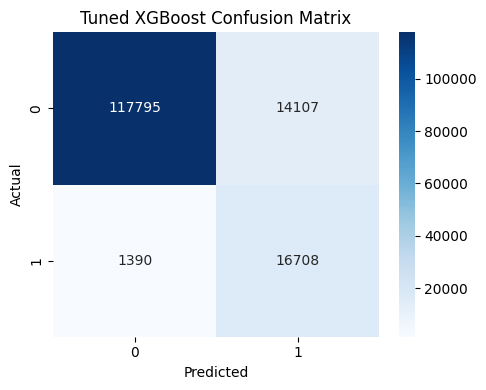

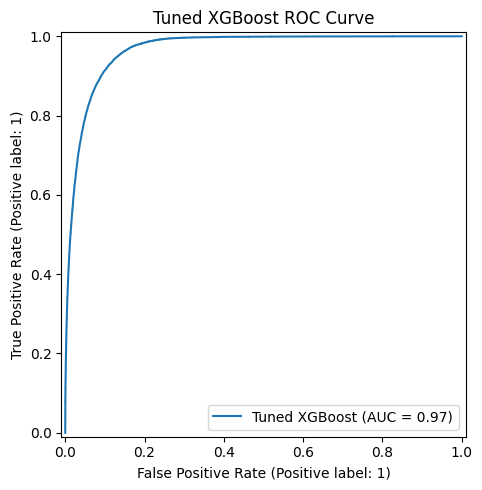

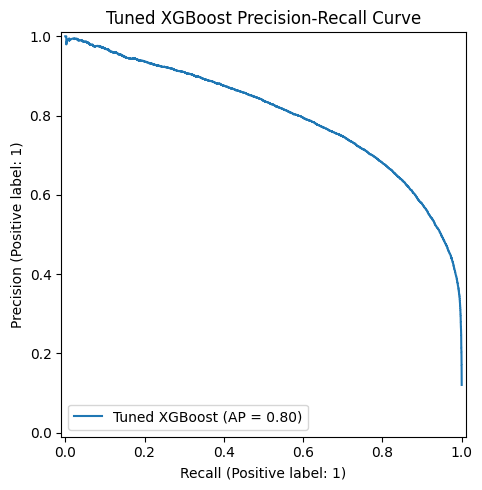

Step 29 Completed: Tuned model evaluated.
Key Finding: The tuned parameters achieved a Validation ROC AUC of 0.967295.\n


In [6]:
# ==============================================================================
# Step 29: Evaluate the Tuned Model on the Validation Set
# ==============================================================================
tuned_model_name = f"Tuned {best_baseline_name}"
tuned_res = evaluate_and_plot(tuned_model, X_train, y_train, X_val, y_val, tuned_model_name)

print("Step 29 Completed: Tuned model evaluated.")
print(f"Key Finding: The tuned parameters achieved a Validation ROC AUC of {tuned_res['ROC AUC']:.6f}.\\n")


In [7]:
# ==============================================================================
# Step 30: Select Final Champion Model
# ==============================================================================
# Add the tuned results to our original results list
results_list.append(tuned_res)

# Sort everything again to see who is truly #1
final_comparison_df = pd.DataFrame(results_list).sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

print("--- Final Model Comparison ---")
display(final_comparison_df)

# Programmatically select the absolute best model from the final dataframe
champion_name = final_comparison_df.iloc[0]['Model']
champion_score = final_comparison_df.iloc[0]['ROC AUC']

# Determine if the Champion is the "Tuned" version or a "Baseline" version
if champion_name == tuned_model_name:
    final_champion_model = tuned_model
else:
    final_champion_model = models[champion_name]

print("Step 30 Completed: Comprehensive comparison generated.")
print(f"Key Finding: The ultimate Champion Model is **{champion_name}** with a ROC AUC of {champion_score:.6f}.\n")


--- Final Model Comparison ---


,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Tuned XGBoost,0.906875,0.896687,0.542203,0.923196,0.683172,0.967295
1,XGBoost,0.883287,0.881980,0.505879,0.939109,0.657549,0.964715
2,Deep Neural Network,0.933947,0.931380,0.732084,0.680186,0.705181,0.962322
3,LightGBM,0.862433,0.862693,0.465917,0.943419,0.623776,0.958702
4,Logistic Regression,0.868880,0.870053,0.479093,0.882528,0.621044,0.943918
5,Random Forest,0.847242,0.847580,0.438429,0.937396,0.597433,0.942966
6,Decision Tree,0.847767,0.848687,0.438708,0.909438,0.591891,0.937863


Step 30 Completed: Comprehensive comparison generated.
Key Finding: The ultimate Champion Model is **Tuned XGBoost** with a ROC AUC of 0.967295.



,Feature,Importance
35,cat__contact_unknown,0.149212
50,cat__poutcome_success,0.141548
3,num__duration,0.092398
43,cat__month_mar,0.077288
51,cat__poutcome_unknown,0.045062
29,cat__housing_no,0.043757
46,cat__month_oct,0.031729
30,cat__housing_yes,0.030101
47,cat__month_sep,0.021621
42,cat__month_jun,0.020764


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15936\2241457947.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='magma')


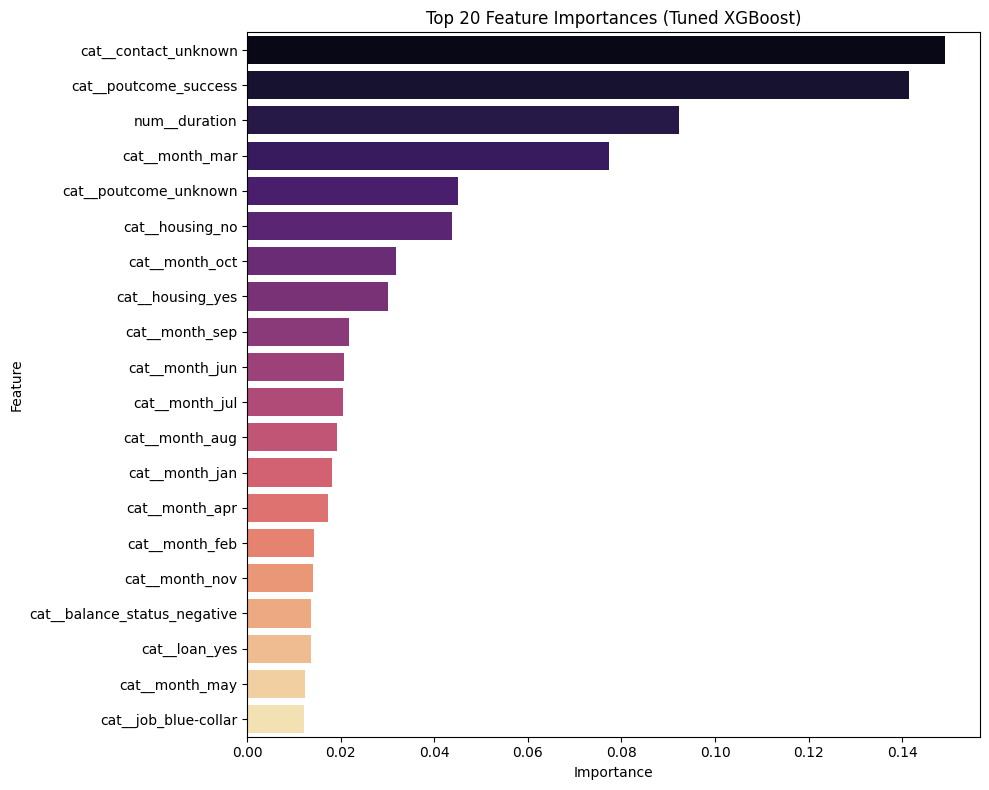

Step 31 Completed: Feature importances extracted, printed, and graphed.


In [8]:
# ==============================================================================
# Step 31: Feature Importance Visualization (Dynamic Extraction)
# ==============================================================================
# Get feature names from preprocessor
preprocessor = joblib.load('../models/preprocessor.joblib')
try:
    feature_names = list(preprocessor.get_feature_names_out())
except:
    feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

# Extract importances based on model type
importances = None
if hasattr(final_champion_model, 'feature_importances_'):
    importances = final_champion_model.feature_importances_
elif hasattr(final_champion_model, 'coef_'):
    importances = np.abs(final_champion_model.coef_[0])

if importances is not None:
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

    # Display all features
    pd.set_option('display.max_rows', None)
    display(feat_imp_df)

    # Plot top 20
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='magma')
    plt.title(f"Top 20 Feature Importances ({champion_name})")
    plt.tight_layout()
    plt.savefig('../charts/08_Feature_Importance.png', bbox_inches='tight')
    plt.show()
    print("Step 31 Completed: Feature importances extracted, printed, and graphed.")
else:
    print("Step 31 Note: The Champion Model does not support native feature importance extraction (e.g., Neural Network). Skipping plot.")


In [9]:
# ==============================================================================
# Step 32: Final Prediction on Test Data (Kaggle Submission)
# ==============================================================================
# Retrain best model on the FULL training dataset for maximum knowledge before predicting test data
final_champion_model.fit(X_train_full, y_train_full)

# Predict probabilities on unseen test set
final_test_probabilities = final_champion_model.predict_proba(X_test)[:, 1]

submission_df = pd.DataFrame({
    'id': test_id,
    'y': final_test_probabilities
})
submission_df.to_csv('../data/final_submission11.csv', index=False)

print("Step 32 Completed: Predictions generated on X_test.")
print("Key Finding: 'final_submission.csv' created. Upload this file directly to the Kaggle competition.\n")


Step 32 Completed: Predictions generated on X_test.
Key Finding: 'final_submission.csv' created. Upload this file directly to the Kaggle competition.



In [10]:
# ==============================================================================
# Step 33: Save the Final Model Locally
# ==============================================================================
# Standardized filename so the Streamlit App doesn't break if the best model changes
model_path = '../models/champion_model.joblib'
joblib.dump(final_champion_model, model_path)

print(f"Step 33 Completed: Champion model ({champion_name}) saved securely to {model_path}.")
print("Key Finding: Model serialization complete for Streamlit Dashboard deployment.\n")


Step 33 Completed: Champion model (Tuned XGBoost) saved securely to ../models/champion_model.joblib.
Key Finding: Model serialization complete for Streamlit Dashboard deployment.



In [11]:
# ==============================================================================
# Step 34: Load the Saved Model and Make a Sample Prediction
# ==============================================================================
loaded_model = joblib.load(model_path)
sample_customer = X_test[0].reshape(1, -1)
sample_pred = loaded_model.predict(sample_customer)
sample_prob = loaded_model.predict_proba(sample_customer)[0][1]

print("Step 34 Completed: Saved model loaded successfully.")
print(f"Key Finding: Sample Customer 1 - Predicted Class: {sample_pred[0]}, Probability of Subscribing: {sample_prob:.4f}")
print("PIPELINE EXECUTION COMPLETE.")


Step 34 Completed: Saved model loaded successfully.
Key Finding: Sample Customer 1 - Predicted Class: 0, Probability of Subscribing: 0.0069
PIPELINE EXECUTION COMPLETE.
